In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

df_all = pd.concat([df_train, df_test], ignore_index=True)
print(f"Total samples: {df_all.shape[0]}")

Total samples: 299534


In [3]:
df_all.head();

In [4]:
df_all.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299534 entries, 0 to 299533
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_duration       299534 non-null  float64
 1   distance_traveled   299534 non-null  float64
 2   num_of_passengers   299534 non-null  float64
 3   fare                299534 non-null  float64
 4   tip                 299534 non-null  int64  
 5   miscellaneous_fees  299534 non-null  float64
 6   total_fare          299534 non-null  float64
 7   surge_applied       299534 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 18.3 MB


In [5]:
df_all['num_of_passengers'] = df_all['num_of_passengers'].astype(int)

In [6]:
df_all.isnull().sum().sum()

np.int64(0)

In [7]:
df_all.duplicated().sum()

np.int64(5556)

In [8]:
df_all.drop_duplicates(inplace=True)

In [9]:
df_all.describe()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
count,293978.000000,293978.000000,293978.000000,293978.000000,293978.000000,293978.000000,293978.000000,293978.000000
mean,1179.906854,5.791619,1.296131,70.310108,13.230541,15.296474,90.247080,0.285858
std,4770.218212,324.539913,0.935360,85.539824,19.998455,12.652303,101.983671,0.451823
min,0.000000,0.020000,0.000000,0.000000,0.000000,-0.500000,0.000000,0.000000
25%,453.000000,1.980000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000
50%,715.000000,3.230000,1.000000,56.250000,9.000000,9.750000,75.637500,0.000000
75%,1107.000000,5.790000,1.000000,97.500000,20.000000,26.525000,127.875000,1.000000
max,86395.000000,145517.600000,9.000000,4466.250000,2500.000000,435.000000,4472.250000,1.000000


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def print_hist(name: str, df) -> None:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[name], bins=20, kde=True)
    plt.title(f'Histogram of {name}')
    plt.show()

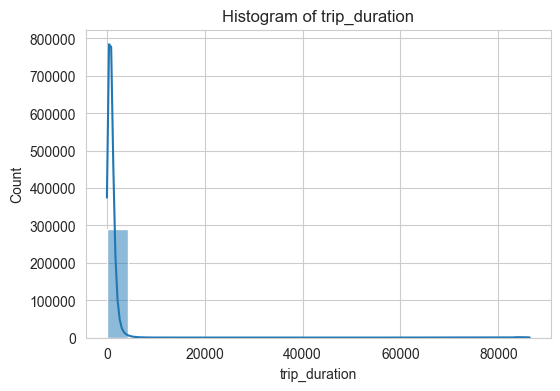

In [11]:
print_hist("trip_duration", df_all)

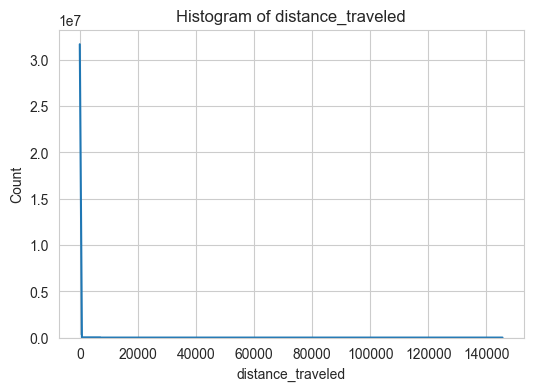

In [12]:
print_hist("distance_traveled", df_all)

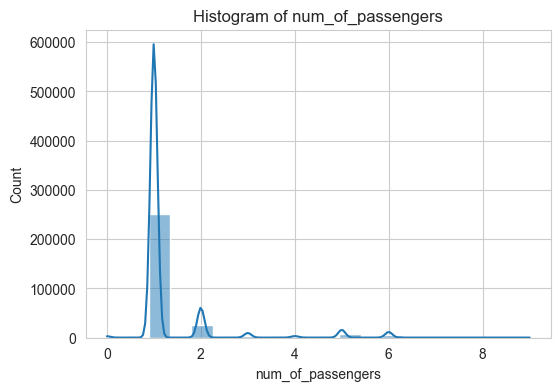

In [13]:
print_hist("num_of_passengers", df_all)

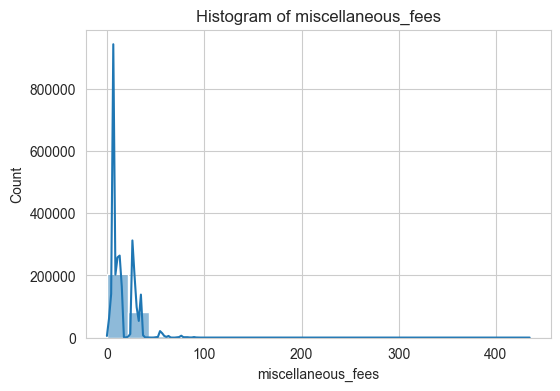

In [14]:
print_hist("miscellaneous_fees", df_all)

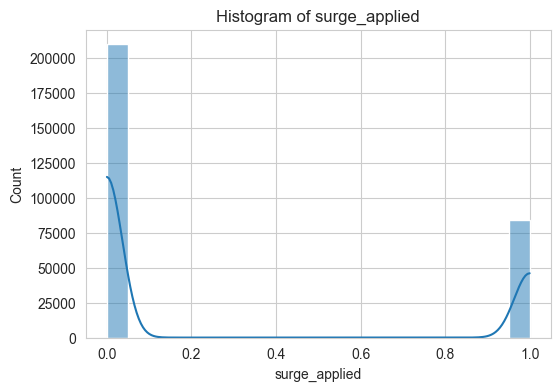

In [15]:
print_hist("surge_applied", df_all)

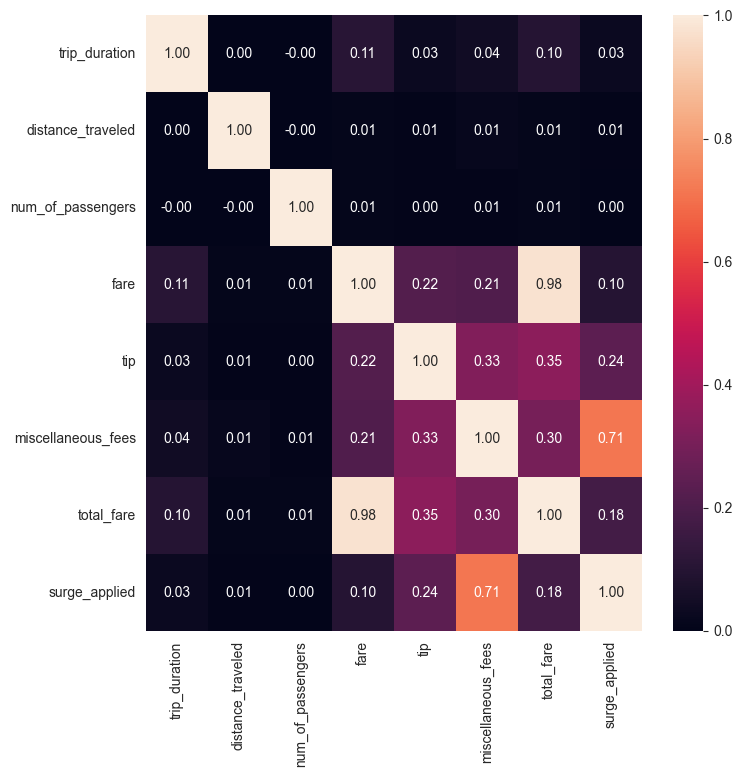

In [16]:
plt.figure(figsize=(8, 8))
sns.heatmap(df_all.corr(), annot=True, fmt=".2f")
plt.show();

In [17]:
from sklearn.model_selection import train_test_split

X = df_all.drop(columns=['total_fare'])
y = df_all['total_fare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 235182, Test: 58796


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

In [20]:
models = {
    "RF": RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "GB": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.7,
        random_state=42
    ),
    "XGB": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.7,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ),
    "LR": SGDRegressor(
        random_state=42,
        alpha=1.0,
        penalty='l2',
        max_iter=1000,
        tol=1e-3
    ),
}

In [21]:
def eval_loss(model_name: str, X_train, y_train, X_test, y_test) -> None:
    model = models[model_name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} - MAE: {mae:.2f}, RMSE: {mse:.2f}, R2: {r2:.2f}")

In [26]:
def cs_score(model_name: str, X_train, y_train) -> None:
    model = models[model_name]
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"Mean R2 CV score for {model_name} moodel:  {np.mean(scores)}")

In [27]:
cs_score("RF", X_train, y_train)
cs_score("GB", X_train, y_train)
cs_score("XGB", X_train, y_train)
cs_score("LR", X_train, y_train)

Mean R2 CV score for RF moodel:  0.9091098178485147
Mean R2 CV score for GB moodel:  0.9957097452366976
Mean R2 CV score for XGB moodel:  0.9442251443204255
Mean R2 CV score for LR moodel:  -5.731123549490975e+28


In [24]:
eval_loss("RF", X_train, y_train, X_test, y_test)
eval_loss("GB", X_train, y_train, X_test, y_test)
eval_loss("XGB", X_train, y_train, X_test, y_test)
eval_loss("LR", X_train, y_train, X_test, y_test)

RF - MAE: 14.92, RMSE: 29.13, R2: 0.91
GB - MAE: 2.72, RMSE: 6.79, R2: 1.00
XGB - MAE: 3.62, RMSE: 17.67, R2: 0.97
LR - MAE: 62440470325945.76, RMSE: 785756612679286.00, R2: -62902964659660635137638400.00
